In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

In [3]:
# Dataset
import zipfile

z = zipfile.ZipFile('archive.zip')

z.extractall()

In [6]:
# EDA(Exploratory Data Analysis)

In [3]:
listyes = os.listdir(r"C:\Users\divya\Downloads\brain_tumor\archive\yes")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir(r"C:\Users\divya\Downloads\brain_tumor\archive\no")
number_files_no = len(listno)
print(number_files_no)

155
98


In [8]:
# Plot

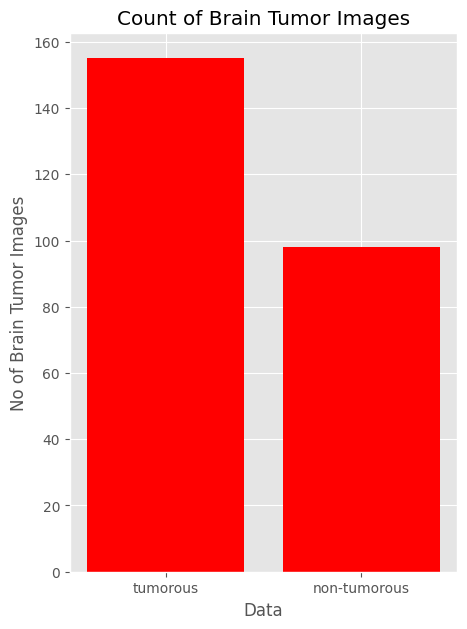

In [4]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [14]:
# Data Augmentation
# 155(61%), 98(39%)
# imbalance

!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 2.5 MB/s eta 0:02:22
   ---------------------------------------- 1.3/351.2 MB 3.2 MB/s eta 0:01:49
   ---------------------------------------- 2.4/351.2 MB 3.8 MB/s eta 0:01:32
   ---------------------------------------- 3.4/351.2 MB 4.2 MB/s eta 0:01:24
    --------------------------------------- 4.7/351.2 MB 4.7 MB/s eta 0:01:15
    --------------------------------------- 6.6/351.2 MB 5.4 MB/s eta 0:01:05
    --------------------------------------- 8.7/351.2 MB 5.9 MB/s eta 0:00:58
   - -------------------------------------- 9.2/351.2 MB 5.6 MB/s eta 0:01:01
   - -------------------------------------- 10.0/351.2 MB 5.4 MB/s eta 0:01:04
   - -------------------------------------- 10.7/351.2 MB 5.1 MB/s eta 0:01:07
   - -------------------------------------- 11.0/351.2 MB 5.0 MB/s eta 0:01:09
   - -------------------------------------- 11.5/351.2 MB 4.7 MB/s e

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.72.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-api-core 2.28.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
google-cloud-compute 1.40.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.26.1 requires

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [6]:
def timing(sec_elapsed):
    h = int(sec_elapsed / (60*60))
    m = int(sec_elapsed % (60*60) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{s}"

In [7]:
def augmented_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=10, 
                      width_shift_range=0.1,
                      height_shift_range=0.1,
                      shear_range=0.1,
                      brightness_range=(0.3, 1.0),
                      horizontal_flip=True,
                      vertical_flip=True,
                      fill_mode='nearest')
    for filename in os.listdir(file_dir):
        image = cv2.imread(file_dir + '/' + filename)
        image = image.reshape((1,) + image.shape)
        save_prefix = 'aug_' + filename[:-4]
        i=0
        for batch in data_gen.flow(x = image, batch_size = 1, save_to_dir = save_to_dir, save_prefix = save_prefix, save_format = "jpg"):
            i+=1
            if i>n_generated_samples:
                break

In [10]:
import time
import os

start_time = time.time()

yes_path = r'C:\Users\divya\Downloads\brain_tumor\archive\yes' 
no_path = r'C:\Users\divya\Downloads\brain_tumor\archive\no'

augmented_data_path = 'augmented_data/'

# ✅ create directories
os.makedirs(augmented_data_path + 'yes', exist_ok=True)
os.makedirs(augmented_data_path + 'no', exist_ok=True)

# run augmentation
augmented_data(file_dir=yes_path, n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
augmented_data(file_dir=no_path, n_generated_samples=9, save_to_dir=augmented_data_path+'no')

end_time = time.time()
execution_time = end_time - start_time

print(execution_time)

47.68144083023071


In [11]:
def data_summary(main_path):
    yes_path = "augmented_data/yes/" 
    no_path = "augmented_data/no/"
    
    n_pos = len(os.listdir(yes_path))
    n_neg = len(os.listdir(no_path))
    
    n = (n_pos + n_neg)
    
    pos_per = (n_pos*100)/n
    neg_per = (n_neg*100)/n
    
    print(f"Number of sample: {n}")
    print(f"{n_pos} Number of positive sample in percentage: {pos_per}%")
    print(f"{n_neg} Number of negative sample in percentage: {neg_per}%")

In [12]:
data_summary(augmented_data_path)

Number of sample: 4128
2169 Number of positive sample in percentage: 52.54360465116279%
1959 Number of negative sample in percentage: 47.45639534883721%


In [13]:
listyes = os.listdir("augmented_data/yes/")
number_files_yes = len(listyes)
print(number_files_yes)

listno = os.listdir("augmented_data/no/")
number_files_no = len(listno)
print(number_files_no)

2169
1959


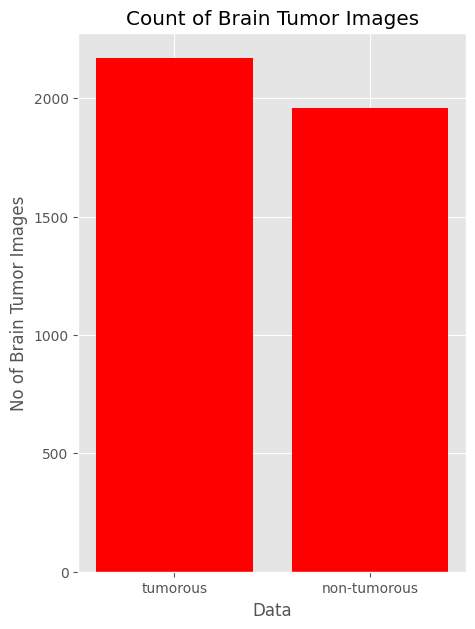

In [14]:
data = {'tumorous': number_files_yes, 'non-tumorous': number_files_no}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(5,7))

plt.bar(typex, values, color="red")

plt.xlabel("Data")
plt.ylabel("No of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

In [ ]:
# Data Preprocessing

In [25]:
# Convert BGR TO GRAY
# GaussianBlur
# Threshold
# Erode
# Dilate
# Find Contours

!pip install imutils

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25891 sha256=3a0ee04f8633efecb9dffa4445bfc89588dd449330b36ad3a64507439e27870d
  Stored in directory: c:\users\divya\appdata\local\pip\cache\wheels\69\2c\66\f966db29490794305257ac3abfe71d4f963f5fc75ba0eb8eb7
Successfully built imutils


  DEPRECATION: Building 'imutils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'imutils'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import imutils
def crop_brain_tumor(image, plot=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    
    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres =cv2.erode(thres, None, iterations = 2)
    thres = cv2.dilate(thres, None, iterations = 2)
    
    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key = cv2.contourArea)
    
    extLeft = tuple(c[c[:,:,0].argmin()][0])
    extRight = tuple(c[c[:,:,0].argmax()][0])
    extTop = tuple(c[c[:,:,1].argmin()][0])
    extBot = tuple(c[c[:,:,1].argmax()][0])
    
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]] 
    
    if plot:
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        
        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        
        plt.title('Original Image')
            
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')
        plt.show()
    return new_image
    

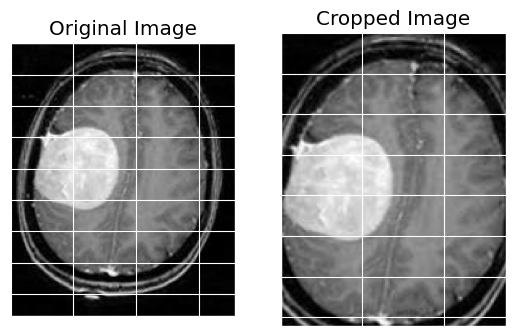

array([[[6, 6, 6],
        [4, 4, 4],
        [3, 3, 3],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [0, 0, 0]],

       [[5, 5, 5],
        [4, 4, 4],
        [2, 2, 2],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [0, 0, 0]],

       [[4, 4, 4],
        [3, 3, 3],
        [1, 1, 1],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [2, 2, 2],
        [6, 6, 6],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       [[5, 5, 5],
        [4, 4, 4],
        [3, 3, 3],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]],

       [[5, 5, 5],
        [4, 4, 4],
        [3, 3, 3],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]]], shape=(181, 139, 3), dtype=uint8)

In [29]:
img = cv2.imread(r'C:\Users\divya\Downloads\brain_tumor\augmented_data\yes\aug_Y_1_0_258.jpg')
crop_brain_tumor(img, True)

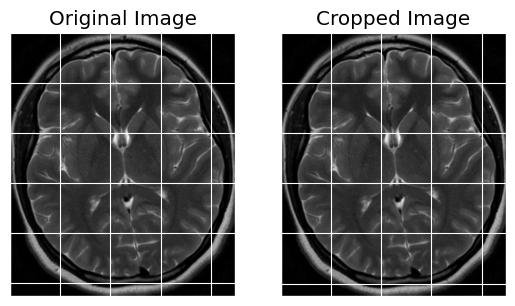

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(525, 449, 3), dtype=uint8)

In [16]:
img = cv2.imread(r'C:\Users\divya\Downloads\brain_tumor\augmented_data\no\aug_N_1_0_2532.jpg')
crop_brain_tumor(img, True)

In [17]:
folder1 = 'augmented_data/no/'
folder2 = 'augmented_data/yes/'

for filename in os.listdir(folder1):
    img = cv2.imread(folder1 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder1 + filename, img)
for filename in os.listdir(folder2):
    img = cv2.imread(folder2 + filename)
    img = crop_brain_tumor(img, False)
    cv2.imwrite(folder2 + filename, img)

In [36]:
# image loading

In [18]:
from sklearn.utils import shuffle
def load_data(dir_list, image_size):
    X=[]
    y=[]
    
    image_width, image_height=image_size
    
    for directory in dir_list:
        for filename in os.listdir(directory):
            image = cv2.imread(directory + '/' + filename)
            image = crop_brain_tumor(image, plot=False)
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation = cv2.INTER_CUBIC)
            image = image/255.00
            X.append(image)
            if directory[-3:] == "yes":
                y.append(1)
            else:
                y.append(0)
    X=np.array(X)
    y=np.array(y)
    
    X,y = shuffle(X,y)
    print(f"Number of example is : {len(X)}")
    print(f"X SHAPE is : {X.shape}")
    print(f"y SHAPE is : {y.shape}")
    return X,y
            

In [19]:
augmented_path = 'augmented_data/'
augmeneted_yes = augmented_path + 'yes'
augmeneted_no = augmented_path + 'no'

IMAGE_WIDTH, IMAGE_HEIGHT = (240,240)

X,y = load_data([augmeneted_yes, augmeneted_no], (IMAGE_WIDTH, IMAGE_HEIGHT))

Number of example is : 4128
X SHAPE is : (4128, 240, 240, 3)
y SHAPE is : (4128,)


In [20]:
def plot_sample_images(X, y, n=50):

    for label in [0,1]:
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))
        
        i = 1        
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                            labelbottom=False, labeltop=False, labelleft=False,
                            labelright=False)
            
            i += 1
        
        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

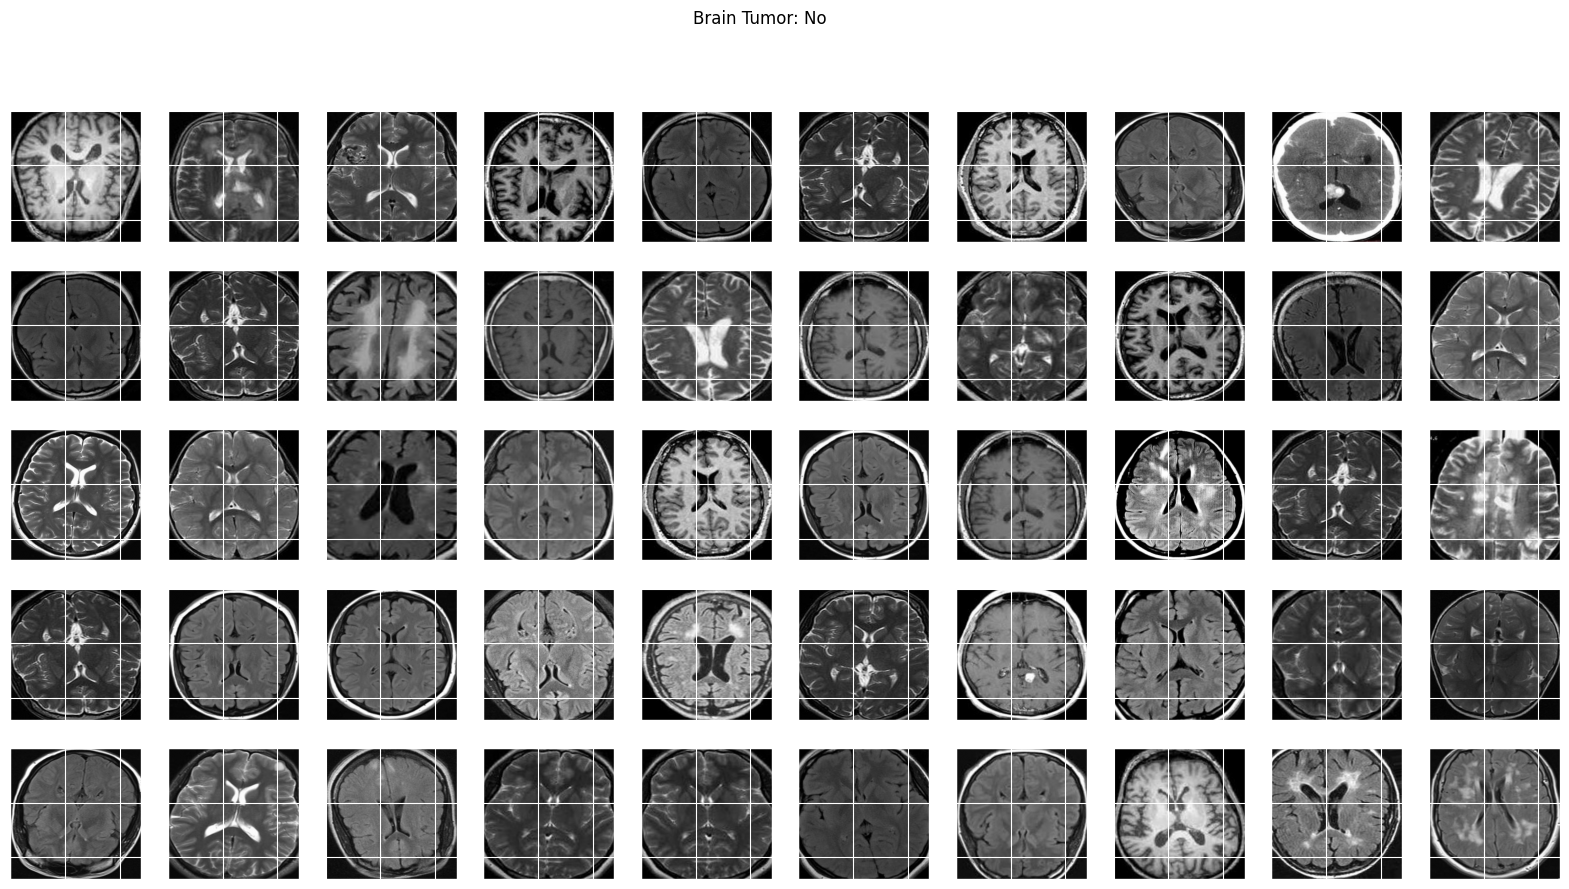

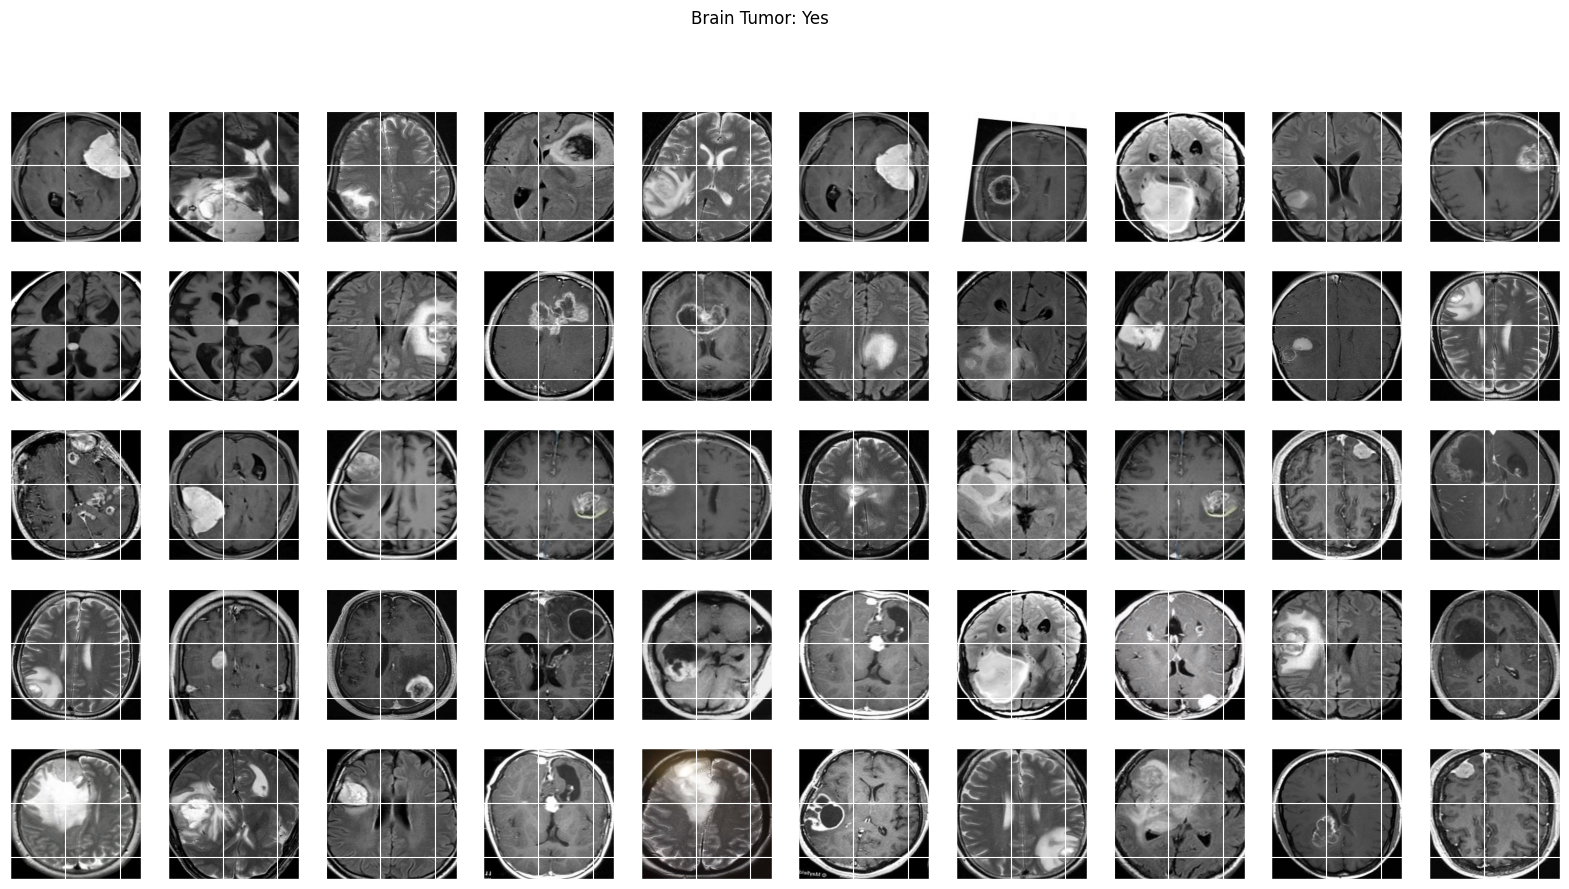

In [21]:
plot_sample_images(X,y)

In [43]:
# Data Spliting
# Train
# Test
# Validation

In [22]:
if not os.path.isdir('tumorous_and_nontumorous'):
    base_dir = 'tumorous_and_nontumorous'
    os.mkdir(base_dir)

In [23]:
if not os.path.isdir('tumorous_and_nontumorous/train'):
    train_dir = os.path.join(base_dir , 'train')
    os.mkdir(train_dir)
if not os.path.isdir('tumorous_and_nontumorous/test'):
    test_dir = os.path.join(base_dir , 'test')
    os.mkdir(test_dir)
if not os.path.isdir('tumorous_and_nontumorous/valid'):
    valid_dir = os.path.join(base_dir , 'valid')
    os.mkdir(valid_dir)

In [34]:
import os
import shutil

# define base dirs
train_dir = 'tumorous_and_nontumorous/train'
test_dir = 'tumorous_and_nontumorous/test'
valid_dir = 'tumorous_and_nontumorous/valid'

# define class dirs FIRST (always)
infected_train_dir = os.path.join(train_dir, 'tumorous')
infected_test_dir = os.path.join(test_dir, 'tumorous')
infected_valid_dir = os.path.join(valid_dir, 'tumorous')

healthy_train_dir = os.path.join(train_dir, 'nontumorous')
healthy_test_dir = os.path.join(test_dir, 'nontumorous')
healthy_valid_dir = os.path.join(valid_dir, 'nontumorous')

# then create them safely
os.makedirs(infected_train_dir, exist_ok=True)
os.makedirs(infected_test_dir, exist_ok=True)
os.makedirs(infected_valid_dir, exist_ok=True)

os.makedirs(healthy_train_dir, exist_ok=True)
os.makedirs(healthy_test_dir, exist_ok=True)
os.makedirs(healthy_valid_dir, exist_ok=True)

In [35]:
original_dataset_tumorours = os.path.join('augmented_data','yes/')
original_dataset_nontumorours = os.path.join('augmented_data','no/')

In [36]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(0,759):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_train_dir, fname)
    shutil.copyfile(src, dst)

In [37]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(759,922):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src, dst)

In [38]:
files = os.listdir('augmented_data/yes/')
fnames = []
for i in range(922,1085):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_tumorours, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src, dst)

In [88]:
# 80% 10% 10%

In [39]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(0,686):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_train_dir, fname)
    shutil.copyfile(src, dst)

In [40]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(686,833):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src, dst)

In [41]:
files = os.listdir('augmented_data/no/')
fnames = []
for i in range(833,979):
    fnames.append(files[i])
for fname in fnames:
    src = os.path.join(original_dataset_nontumorours, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src, dst)

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,            # reduced
    width_shift_range=0.1,        # reduced
    height_shift_range=0.1,       # reduced

    shear_range=0.1,
    zoom_range=0.2,

    horizontal_flip=True,         # correct usage
    vertical_flip=False,          # usually keep False unless task allows

    fill_mode='nearest'
)

valid_data_gen = ImageDataGenerator(rescale=1./255)
test_data_gen  = ImageDataGenerator(rescale=1./255)

In [3]:
train_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/train/', batch_size=32, target_size=(240,240), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 2169 images belonging to 2 classes.


In [4]:
test_generator = test_data_gen.flow_from_directory(
    'tumorous_and_nontumorous/test/',
    batch_size=32,
    target_size=(240,240),
    class_mode='categorical',
    shuffle=False,        # IMPORTANT
    color_mode='rgb'
)

Found 620 images belonging to 2 classes.


In [5]:
valid_generator = train_datagen.flow_from_directory('tumorous_and_nontumorous/valid/', batch_size=32, target_size=(240,240), class_mode='categorical',shuffle=True, seed = 42, color_mode = 'rgb')


Found 618 images belonging to 2 classes.


In [6]:
class_labels = train_generator.class_indices
class_name = {value: key for (key,value) in class_labels.items()}

In [7]:
class_name

{0: 'nontumorous', 1: 'tumorous'}

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# =========================
# Base Model
# =========================
base_model = VGG19(input_shape=(240,240,3), include_top=False, weights='imagenet')

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# =========================
# Custom Head
# =========================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

# =========================
# Callbacks
# =========================
checkpoint_path = "best_model.keras"

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cp = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lrr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

# =========================
# PHASE 1: Train top layers
# =========================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_steps=len(valid_generator),
    callbacks=[es, cp, lrr]
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 30, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,355,010 (77.65 MB)

 Trainable params: 329,602 (1.26 MB)

 Non-trainable params: 20,025,408 (76.39 MB)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5830 - loss: 0.7367
Epoch 1: val_accuracy improved from None to 0.54531, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 454s 7s/step - accuracy: 0.6372 - loss: 0.6634 - val_accuracy: 0.5453 - val_loss: 0.6733 - learning_rate: 1.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7282 - loss: 0.5417
Epoch 2: val_accuracy improved from 0.54531 to 0.67638, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 553s 8s/step - accuracy: 0.7427 - loss: 0.5116 - val_accuracy: 0.6764 - val_loss: 0.6433 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7828 - loss: 0.4534
Epoch 3: val_accuracy improved from 0.67638 to 0.72168, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 553s 8s/step - a

KeyboardInterrupt: 

In [8]:
from tensorflow.keras.models import load_model

# Load best model
model = load_model(r"C:\Users\divya\Downloads\brain_tumor\best_model.keras")

print("✅ Model loaded successfully")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=len(test_generator),
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

✅ Model loaded successfully
20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.8903 - loss: 0.3025

Test Loss: 0.3025
Test Accuracy: 89.03%


In [8]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# =========================
# LOAD SAVED MODEL (from Phase 1)
# =========================
model = load_model("best_model.keras")

print("\n✅ Loaded model successfully!")

# =========================
# FREEZE ALL LAYERS FIRST
# =========================
for layer in model.layers:
    layer.trainable = False

# =========================
# UNFREEZE LAST FEW LAYERS (Fine-tuning)
# =========================

# Option 1 (simple)
for layer in model.layers[-40:]:
    layer.trainable = True

# ---- OR (better, more precise) ----
# for layer in model.layers:
#     if "block5" in layer.name:
#         layer.trainable = True

# =========================
# VERIFY TRAINABLE LAYERS
# =========================
trainable_count = sum([1 for l in model.layers if l.trainable])
print(f"\n🔥 Trainable layers: {trainable_count}/{len(model.layers)}")

# =========================
# CALLBACKS
# =========================
checkpoint_path = "best_model_finetuned.keras"

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cp = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lrr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

# =========================
# COMPILE (for fine-tuning)
# =========================
model.compile(
    optimizer=SGD(learning_rate=1e-5, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Starting Fine-Tuning (NO restart)...")

# =========================
# CONTINUE TRAINING (ONLY 10 EPOCHS)
# =========================
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,   # 🔥 reduced from 30 → 10
    steps_per_epoch=len(train_generator),
    validation_steps=len(valid_generator),
    callbacks=[es, cp, lrr]
)

# =========================
# SAVE FINAL MODEL
# =========================
model.save("final_model.keras")
print("\n✅ Final model saved!")

# =========================
# EVALUATE ON TEST SET
# =========================
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=len(test_generator),
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


✅ Loaded model successfully!

🔥 Trainable layers: 29/29

🚀 Starting Fine-Tuning (NO restart)...
Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.9409 - loss: 0.1694 
Epoch 1: val_accuracy improved from None to 0.88673, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1751s 26s/step - accuracy: 0.9428 - loss: 0.1592 - val_accuracy: 0.8867 - val_loss: 0.2403 - learning_rate: 1.0000e-05
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.9362 - loss: 0.1449 
Epoch 2: val_accuracy improved from 0.88673 to 0.88835, saving model to best_model_finetuned.keras

Epoch 2: finished saving model to best_model_finetuned.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1866s 27s/step - accuracy: 0.9391 - loss: 0.1474 - val_accuracy: 0.8883 - val_loss: 0.2559 - learning_rate: 1.0000e-05
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 31s/step - accuracy: 0.9558 - loss: 0.1252 
Epoch 3: val_accuracy improved from 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step

Prediction: tumorous
Confidence: 98.89%
Using layer: block5_conv4


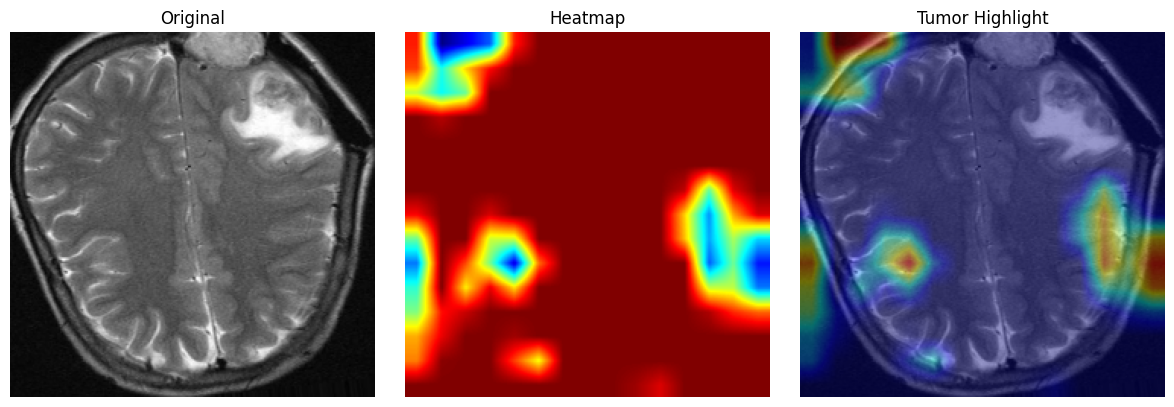

In [3]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# =========================
# LOAD MODEL
# =========================
model = load_model("final_model.keras")

# =========================
# IMAGE PATH
# =========================
img_path = r"C:\Users\divya\Downloads\brain_tumor\tumorous_and_nontumorous\test\tumorous\aug_Y_5_0_698.jpg"

img_size = (240, 240)

# =========================
# PREPROCESS IMAGE
# =========================
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# =========================
# PREDICTION
# =========================
pred = model.predict(img_array)[0]
class_idx = np.argmax(pred)

classes = ['non-tumorous', 'tumorous']

print(f"\nPrediction: {classes[class_idx]}")
print(f"Confidence: {np.max(pred)*100:.2f}%")

# =========================
# GRAD-CAM FUNCTION (FIXED)
# =========================
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 🔥 Convert ONCE to numpy
    heatmap = heatmap.numpy()

    # 🔥 Normalize safely
    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

# =========================
# FIND LAST CONV LAYER
# =========================
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

if last_conv_layer is None:
    raise ValueError("❌ No Conv2D layer found in model!")

print(f"Using layer: {last_conv_layer}")

# =========================
# GENERATE HEATMAP
# =========================
heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer)

# =========================
# SUPERIMPOSE HEATMAP
# =========================
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, img_size)

heatmap = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

# =========================
# DISPLAY RESULTS
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap_colored)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Tumor Highlight")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
from tensorflow.keras.models import load_model

# Load your existing model
model = load_model("final_model.keras")

# Save as .h5
model.save("final_model.h5")

print("✅ Model successfully converted to .h5")

✅ Model successfully converted to .h5
